# Inicializar directorios
Clonar repositorio github
Posicionarse en el directorio raíz

In [1]:
import os
import sys

# ============================================================================
# CONFIGURACIÓN DE DIRECTORIOS
# ============================================================================

# Detectar si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Configurar el directorio de trabajo según el entorno
if IN_COLAB:
    project_dir = '/content/TFMDS'
    os.chdir(project_dir)
else:
    project_dir = r'C:\Users\jmora\Documents\TFMDS'
    os.chdir(project_dir)

# Agregar el directorio del proyecto al path de Python
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print("Directorio de trabajo:", os.getcwd())
print("Python path incluye proyecto:", project_dir in sys.path)

Directorio de trabajo: C:\Users\jmora\Documents\TFMDS
Python path incluye proyecto: True


In [2]:
# ============================================================================
# IMPORTACIONES BASE Y VERSIÓN
# ============================================================================
import os, sys
import pandas as pd
import numpy as np
import time

import torch
import pytorch_lightning as pl
from neuralforecast import NeuralForecast, __version__ as nf_version
from neuralforecast.models import TFT
from neuralforecast.losses.pytorch import MAE

# Importar utilidades desde la carpeta 'lib' evitando el paquete
lib_dir = os.path.join(os.getcwd(), 'lib')
if lib_dir not in sys.path:
    sys.path.insert(0, lib_dir)

from lib.dl_utils import (
    preparar_datos_neuralforecast,
    seleccionar_features_exogenas,
    reconstruir_predicciones,
    preparar_variables_estaticas,
)
from lib.metricas import calcular_metricas, resumen_metricas
from lib.graficos_dl import (
    grafico_prediccion_diaria_agregada,
    grafico_prediccion_por_cluster,
    grafico_productos_por_cluster,
    dashboard_metricas_dl,
)

print(f"torch: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"neuralforecast: {nf_version}")


c:\Users\jmora\Documents\TFMDS\venv\Lib\site-packages\torchmetrics\utilities\imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


torch: 2.9.1+cpu
pytorch_lightning: 2.5.0
neuralforecast: 1.6.4


# Lectura de datos preparados para Deep Learning

In [3]:
# ============================================================================
# LECTURA DE DATOS
# ============================================================================

print("\n" + "="*100)
print("📂 CARGANDO DATOS PARA DEEP LEARNING")
print("="*100)

# Datos normalizados para entrenamiento
df_train_raw = pd.read_csv('datos/df_train_dl.csv', sep=';', parse_dates=['idSecuencia'])
df_test_raw = pd.read_csv('datos/df_test_dl.csv', sep=';', parse_dates=['idSecuencia'])

print(f"\n✅ Datos cargados:")
print(f"   Train: {df_train_raw.shape}")
print(f"   Test:  {df_test_raw.shape}")


📂 CARGANDO DATOS PARA DEEP LEARNING

✅ Datos cargados:
   Train: (625800, 27)
   Test:  (27714, 27)

✅ Datos cargados:
   Train: (625800, 27)
   Test:  (27714, 27)


# Preparación de datos para NeuralForecast

In [4]:
# ============================================================================
# PREPARACIÓN DE DATOS PARA NEURALFORECAST
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO DATOS PARA NEURALFORECAST")
print("="*100)

# Convertir al formato NeuralForecast (unique_id, ds, y)
df_train_nf, df_test_nf = preparar_datos_neuralforecast(
    df_train_raw,
    df_test_raw,
    col_fecha='idSecuencia',
    col_producto='producto',
    col_target='udsVenta'
)

print(f"\n✅ Datos convertidos a formato NeuralForecast")
print(f"   Train NF: {df_train_nf.shape}")
print(f"   Test NF:  {df_test_nf.shape}")


🔧 PREPARANDO DATOS PARA NEURALFORECAST

✅ Datos convertidos a formato NeuralForecast
   Train NF: (625800, 27)
   Test NF:  (27714, 27)

✅ Datos convertidos a formato NeuralForecast
   Train NF: (625800, 27)
   Test NF:  (27714, 27)


# Configuración del modelo TFT

## Preparar variables estáticas

In [5]:
# ============================================================================
# PREPARAR VARIABLES ESTÁTICAS
# ============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO VARIABLES ESTÁTICAS")
print("="*100)

# Definir columnas estáticas (que no varían en el tiempo)
stat_exog_list = ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']

# Separar variables estáticas en DataFrame aparte
df_train_nf, df_test_nf, static_df = preparar_variables_estaticas(
    df_train_nf,
    df_test_nf,
    stat_exog_list
)


🔧 PREPARANDO VARIABLES ESTÁTICAS

✅ Variables estáticas extraídas:
   Columnas estáticas: ['Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3']
   Shape static_df: (894, 5)
   Productos únicos: 894

📊 Datasets temporales actualizados:
   Train: (625800, 23) (eliminadas 4 columnas)
   Test:  (27714, 23) (eliminadas 4 columnas)


In [6]:
# =============================================================================
# LIMPIEZA DE FEATURES HISTÓRICAS (evitar NaN al inicio del test)
# =============================================================================

print("\n" + "="*100)
print("🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)")
print("="*100)

# Definir la lista de features históricas que usa el modelo
hist_exog_list = [
    'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
    'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'media_mes_anterior',
    'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
]

# Comprobar existencia de columnas
def _check_missing(df, cols):
    return [c for c in cols if c not in df.columns]

missing_train = _check_missing(df_train_nf, hist_exog_list)
missing_test = _check_missing(df_test_nf, hist_exog_list)

if missing_train:
    print(f"⚠️ Faltan columnas en train: {missing_train}")
if missing_test:
    print(f"⚠️ Faltan columnas en test: {missing_test}")

cols_ok = [c for c in hist_exog_list if c in df_train_nf.columns and c in df_test_nf.columns]

if cols_ok:
    # Estadísticas antes
    na_train_before = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_before = int(df_test_nf[cols_ok].isna().sum().sum())

    # Forward fill por serie (unique_id) y rellenar remanentes al inicio con 0
    df_train_nf[cols_ok] = (
        df_train_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )
    df_test_nf[cols_ok] = (
        df_test_nf.groupby('unique_id', observed=True)[cols_ok]
        .ffill()
        .fillna(0)
    )

    # Asegurar tipos numéricos (por si hubiera strings)
    for df_tmp in (df_train_nf, df_test_nf):
        for c in cols_ok:
            df_tmp[c] = pd.to_numeric(df_tmp[c], errors='coerce').fillna(0)

    # Estadísticas después
    na_train_after = int(df_train_nf[cols_ok].isna().sum().sum())
    na_test_after = int(df_test_nf[cols_ok].isna().sum().sum())

    print(f"✅ NaNs en train: {na_train_before} → {na_train_after}")
    print(f"✅ NaNs en test:  {na_test_before} → {na_test_after}")
else:
    print("⚠️ No hay columnas históricas válidas para limpiar.")

# Comprobación de contexto mínimo: filas previas por producto
min_hist = (
    df_train_nf.groupby('unique_id', observed=True)['ds']
    .count()
    .min()
)
print(f"ℹ️ Mínimo historial por producto en train: {min_hist} filas")
print("   Si es < input_size, considera reducir input_size o filtrar productos.")


🧹 LIMPIANDO FEATURES HISTÓRICAS (hist_exog_list)
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.
✅ NaNs en train: 4 → 0
✅ NaNs en test:  0 → 0
ℹ️ Mínimo historial por producto en train: 700 filas
   Si es < input_size, considera reducir input_size o filtrar productos.


## Configuración del modelo

In [7]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO TFT (Temporal Fusion Transformer)
# ============================================================================

print("\n" + "="*100)
print("🧠 CONFIGURANDO MODELO TFT")
print("="*100)

# Horizonte de predicción (30 días)
HORIZON = 30

# Hiperparámetros del modelo TFT
modelo_tft = TFT(
    h=HORIZON,                      # Horizonte de predicción
    input_size=60,                  # Ventana de entrada (últimos 60 días)
    loss=MAE(),                     # Función de pérdida
    max_steps=500,                  # Número máximo de pasos de entrenamiento
    hidden_size=128,                # Tamaño de capa oculta
    n_head=4,                       # Número de attention heads
    dropout=0.1,                    # Dropout para regularización
    learning_rate=1e-3,             # Learning rate
    scaler_type='standard',         # Escalado: 'standard', 'robust', 'minmax', 'identity'
    batch_size=32,                  # Batch size
    random_seed=42,                 # Semilla aleatoria

    # 🔮 FUTURAS (valores conocidos a futuro)
    futr_exog_list=[
        'bolOpen', 'bolHoliday', 'bolPromocion',
        'dia_semana_sin', 'dia_semana_cos',
        'mes_sin', 'mes_cos',
        'trimestre_sin', 'trimestre_cos'
    ],

    # 🕒 HISTÓRICAS (solo pasado)
    hist_exog_list=[
        'lag_ventas_1', 'lag_ventas_2', 'lag_ventas_3', 'lag_ventas_4',
        'lag_ventas_5', 'lag_ventas_6', 'lag_ventas_7', 'media_mes_anterior',
        'EWMA_corto', 'EWMA_largo', 'Tendencia_EWMA'
    ],
    
    # 🏷️ ESTÁTICAS (características del producto)
    stat_exog_list=stat_exog_list,
    
    enable_progress_bar=True
)

print("\n✅ Modelo TFT configurado:")
print(f"   Horizonte: {HORIZON} días")
print(f"   Input size: {60} días")
print(f"   Hidden size: {128}")
print(f"   Attention heads: {4}")
print(f"   Max steps: {500}")
print(f"   Variables futuras: {len(modelo_tft.futr_exog_list)}")
print(f"   Variables históricas: {len(modelo_tft.hist_exog_list)}")
print(f"   Variables estáticas: {len(modelo_tft.stat_exog_list)}")

Seed set to 42



🧠 CONFIGURANDO MODELO TFT

✅ Modelo TFT configurado:
   Horizonte: 30 días
   Input size: 60 días
   Hidden size: 128
   Attention heads: 4
   Max steps: 500
   Variables futuras: 9
   Variables históricas: 11
   Variables estáticas: 4


# Entrenamiento del modelo

In [8]:
# ============================================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================================

print("\n" + "="*100)
print("🚀 INICIANDO ENTRENAMIENTO TFT")
print("="*100)

# Crear instancia de NeuralForecast
nf = NeuralForecast(
    models=[modelo_tft],
    freq='D'  # Frecuencia diaria
)

# Entrenar el modelo
print("\n⏳ Entrenando modelo TFT...")
start_time = time.perf_counter()

nf.fit(df=df_train_nf, static_df=static_df)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Entrenamiento completado en {elapsed:.2f} segundos ({elapsed/60:.2f} minutos)")


🚀 INICIANDO ENTRENAMIENTO TFT

⏳ Entrenando modelo TFT...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


✅ Entrenamiento completado en 15487.24 segundos (258.12 minutos)


# Predicción sobre el conjunto de test

In [9]:
# ============================================================================
# PREDICCIÓN
# ============================================================================

print("\n" + "="*100)
print("🔮 GENERANDO PREDICCIONES")
print("="*100)

# Realizar predicciones
print("\n⏳ Generando predicciones en test set...")
start_time = time.perf_counter()

y_hat = nf.predict(futr_df=df_test_nf)

elapsed = time.perf_counter() - start_time

print(f"\n✅ Predicciones generadas en {elapsed:.2f} segundos")
print(f"   Shape predicciones: {y_hat.shape}")
print(f"\n📋 Primeras predicciones:")
print(y_hat.head())


🔮 GENERANDO PREDICCIONES

⏳ Generando predicciones en test set...


Predicting: |          | 0/? [00:00<?, ?it/s]


✅ Predicciones generadas en 8.23 segundos
   Shape predicciones: (26820, 2)

📋 Primeras predicciones:
                  ds       TFT
unique_id                     
1         2024-10-06  0.211879
1         2024-10-07  7.313151
1         2024-10-08  7.212590
1         2024-10-09  7.156686
1         2024-10-10  7.163892


# Reconstruir predicciones en formato original

In [10]:
# =============================================================================
# PREDICCIONES EN FORMATO NEURALFORECAST (SIN RECONSTRUCCIÓN/ESCALADO)
# =============================================================================

print("\n" + "="*100)
print("🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS")
print("="*100)

# y_hat puede venir con 'unique_id' como índice; normalizamos para merge
if y_hat.index.name == 'unique_id':
    y_hat = y_hat.reset_index()

# Asegurar que existen columnas necesarias
required_cols_pred = {'unique_id', 'ds'}
if not required_cols_pred.issubset(set(y_hat.columns)):
    raise ValueError(f"Faltan columnas en y_hat para merge: {required_cols_pred - set(y_hat.columns)}")

# Renombrar columna del modelo a 'prediccion' sin copiar innecesariamente
if 'TFT' in y_hat.columns:
    y_hat = y_hat.rename(columns={'TFT': 'prediccion'})
elif 'prediccion' not in y_hat.columns:
    # Si el modelo cambió el nombre, tomamos la primera columna de predicción distinta a ['unique_id','ds']
    pred_cols = [c for c in y_hat.columns if c not in ['unique_id', 'ds']]
    if not pred_cols:
        raise ValueError("No se encontró columna de predicción en y_hat.")
    y_hat = y_hat.rename(columns={pred_cols[0]: 'prediccion'})

# Merge con el test en formato NF (evitando copias)
df_test_pred = df_test_nf[['unique_id', 'ds', 'y']].merge(
    y_hat[['unique_id', 'ds', 'prediccion']],
    on=['unique_id', 'ds'],
    how='left'
)

# Columnas compatibles con funciones de gráficos existentes
df_test_pred['idSecuencia'] = df_test_pred['ds']
df_test_pred['producto'] = df_test_pred['unique_id']
# Mantener convención 'udsVenta' para métricas existentes
df_test_pred['udsVenta'] = df_test_pred['y']

# Clip de valores negativos a 0
df_test_pred['prediccion'] = df_test_pred['prediccion'].clip(lower=0)

# Calcular errores
df_test_pred['error'] = df_test_pred['prediccion'] - df_test_pred['udsVenta']
df_test_pred['error_abs'] = np.abs(df_test_pred['error'])

print(f"\n✅ Dataset de predicciones listo:")
print(f"   Shape: {df_test_pred.shape}")
print(f"   Predicciones no nulas: {df_test_pred['prediccion'].notna().sum()}")
print(f"\n📊 Estadísticas del error:")
print(f"   Error medio: {df_test_pred['error'].mean():.2f} unidades")
print(f"   Error abs medio: {df_test_pred['error_abs'].mean():.2f} unidades")


🔧 PREPARANDO PREDICCIONES PARA MÉTRICAS Y GRÁFICOS

✅ Dataset de predicciones listo:
   Shape: (27714, 9)
   Predicciones no nulas: 26820

📊 Estadísticas del error:
   Error medio: -0.64 unidades
   Error abs medio: 1.18 unidades


# Cálculo de métricas

In [11]:
# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("📊 CÁLCULO DE MÉTRICAS")
print("="*100)

# Filtrar valores válidos (sin NaN)
df_valid = df_test_pred.dropna(subset=['prediccion', 'udsVenta'])

# Calcular métricas
metricas_tft = calcular_metricas(
    y=df_valid['udsVenta'],
    y_pred=df_valid['prediccion'],
    name='TFT'
)

# Mostrar resumen
resumen_metricas([metricas_tft])

# Guardar para comparación posterior
todas_metricas = [metricas_tft]


📊 CÁLCULO DE MÉTRICAS

📊 RESUMEN DE MÉTRICAS
           Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
                 TFT 1.1758 5.5466 2.3551 0.1783     64.97     168.69 0.7277    86.76

🏆 Mejor modelo: TFT (RMSE: 2.3551)


# Visualizaciones

## Preparación: Reconstruir columna Cluster desde one-hot encoding

In [12]:
# ============================================================================
# RECONSTRUIR COLUMNA CLUSTER DESDE static_df (one-hot estático)
# ============================================================================

# Si ya existe 'Cluster' en el dataset de predicciones, la respetamos
if 'Cluster' in df_test_pred.columns:
    try:
        df_test_pred['Cluster'] = df_test_pred['Cluster'].astype('Int64')
    except Exception:
        pass
    print("\n✅ Columna 'Cluster' ya presente en df_test_pred.")
    print("   Distribución:")
    print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
else:
    # Intentar reconstruir desde static_df (variables estáticas por unique_id)
    cluster_cols = [c for c in static_df.columns if c.startswith('Cluster_')]

    if cluster_cols:
        # Ordenar columnas y calcular argmax por unique_id
        cluster_cols = sorted(cluster_cols, key=lambda x: int(x.split('_')[1]))
        static_map = static_df[['unique_id'] + cluster_cols].copy()
        cluster_idx = static_map[cluster_cols].to_numpy().argmax(axis=1)
        static_map['Cluster'] = cluster_idx

        # Unir al dataset de predicciones
        df_test_pred = df_test_pred.merge(
            static_map[['unique_id', 'Cluster']],
            on='unique_id',
            how='left'
        )

        print(f"\n✅ 'Cluster' reconstruido desde static_df ({len(cluster_cols)} columnas one-hot).")
        print("   Distribución:")
        print(df_test_pred['Cluster'].value_counts(dropna=False).sort_index())
    else:
        print("\n⚠️ No se encontraron columnas 'Cluster_*' en static_df.")
        print("   Las visualizaciones por cluster no estarán disponibles.")


✅ 'Cluster' reconstruido desde static_df (4 columnas one-hot).
   Distribución:
Cluster
0     9331
1     3286
2      496
3    14601
Name: count, dtype: int64


## 1. Predicción diaria agregada (todos los productos)

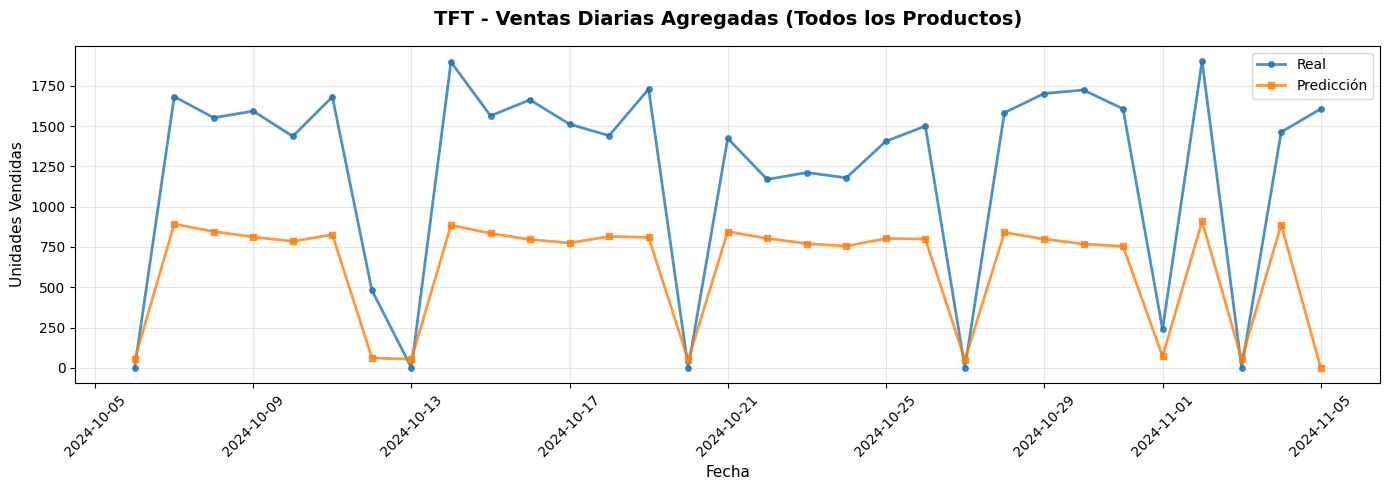


📊 Estadísticas diarias agregadas:
   MAE diario:  621.52
   RMSE diario: 714.02
   Error % medio: inf%


In [13]:
grafico_prediccion_diaria_agregada(
    df=df_test_pred,
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    titulo='TFT - Ventas Diarias Agregadas (Todos los Productos)',
    figsize=(14, 5)
)

## 2. Predicciones por Cluster

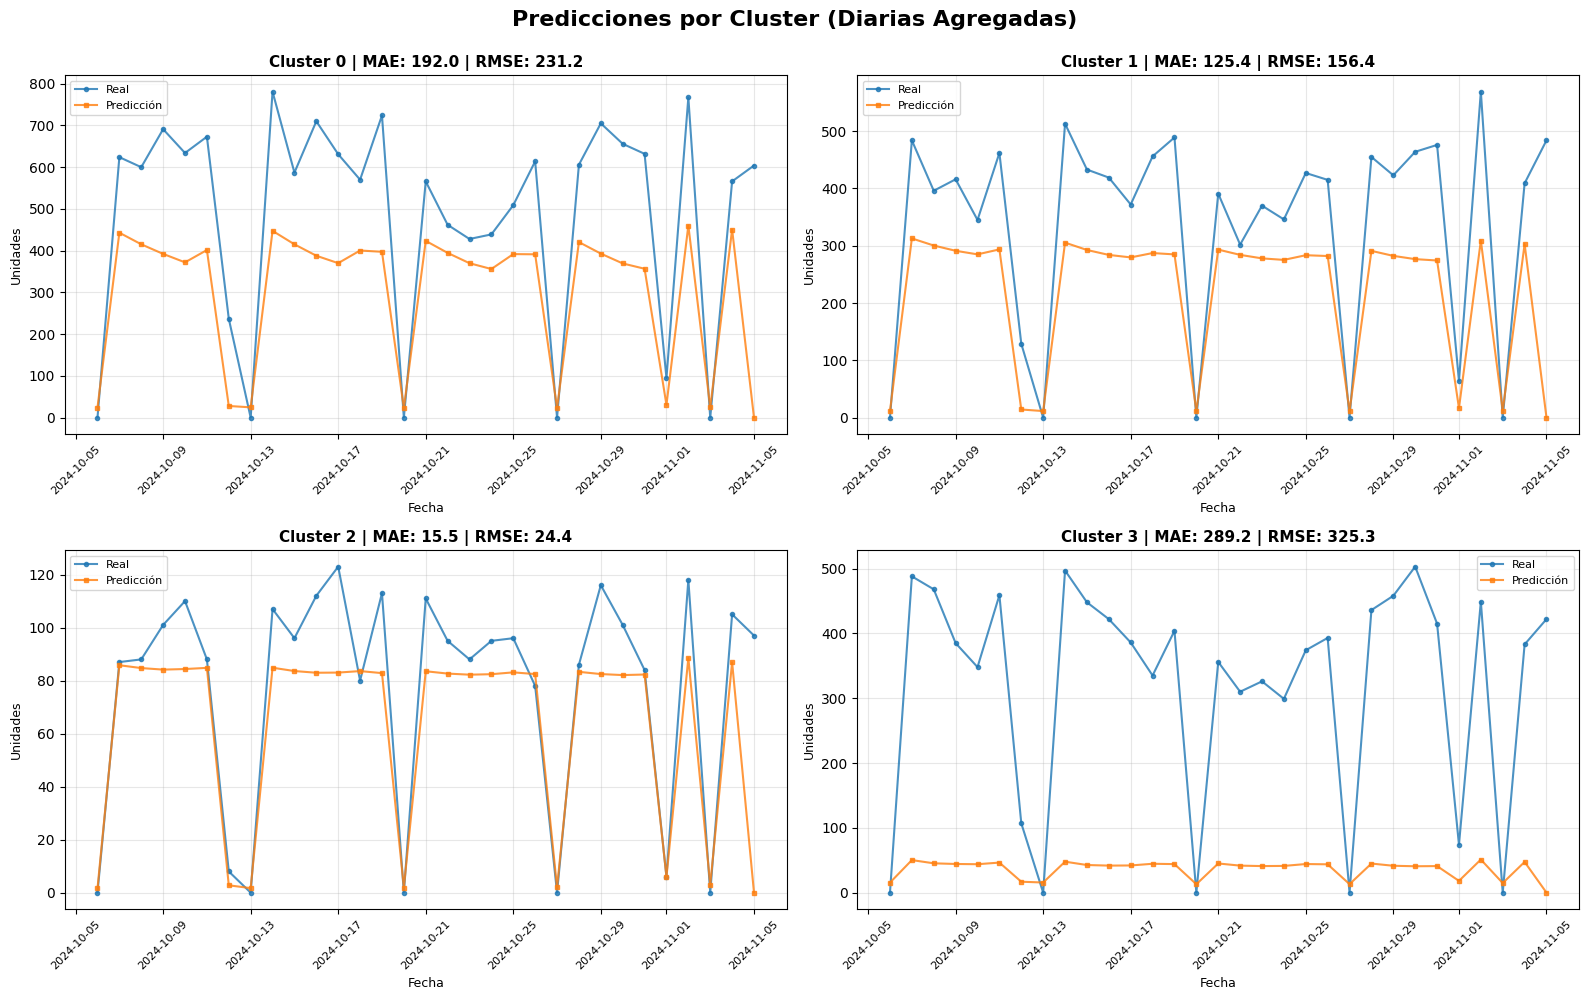

In [14]:
grafico_prediccion_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    figsize=(16, 10)
)

## 3. Top 2 productos por Cluster

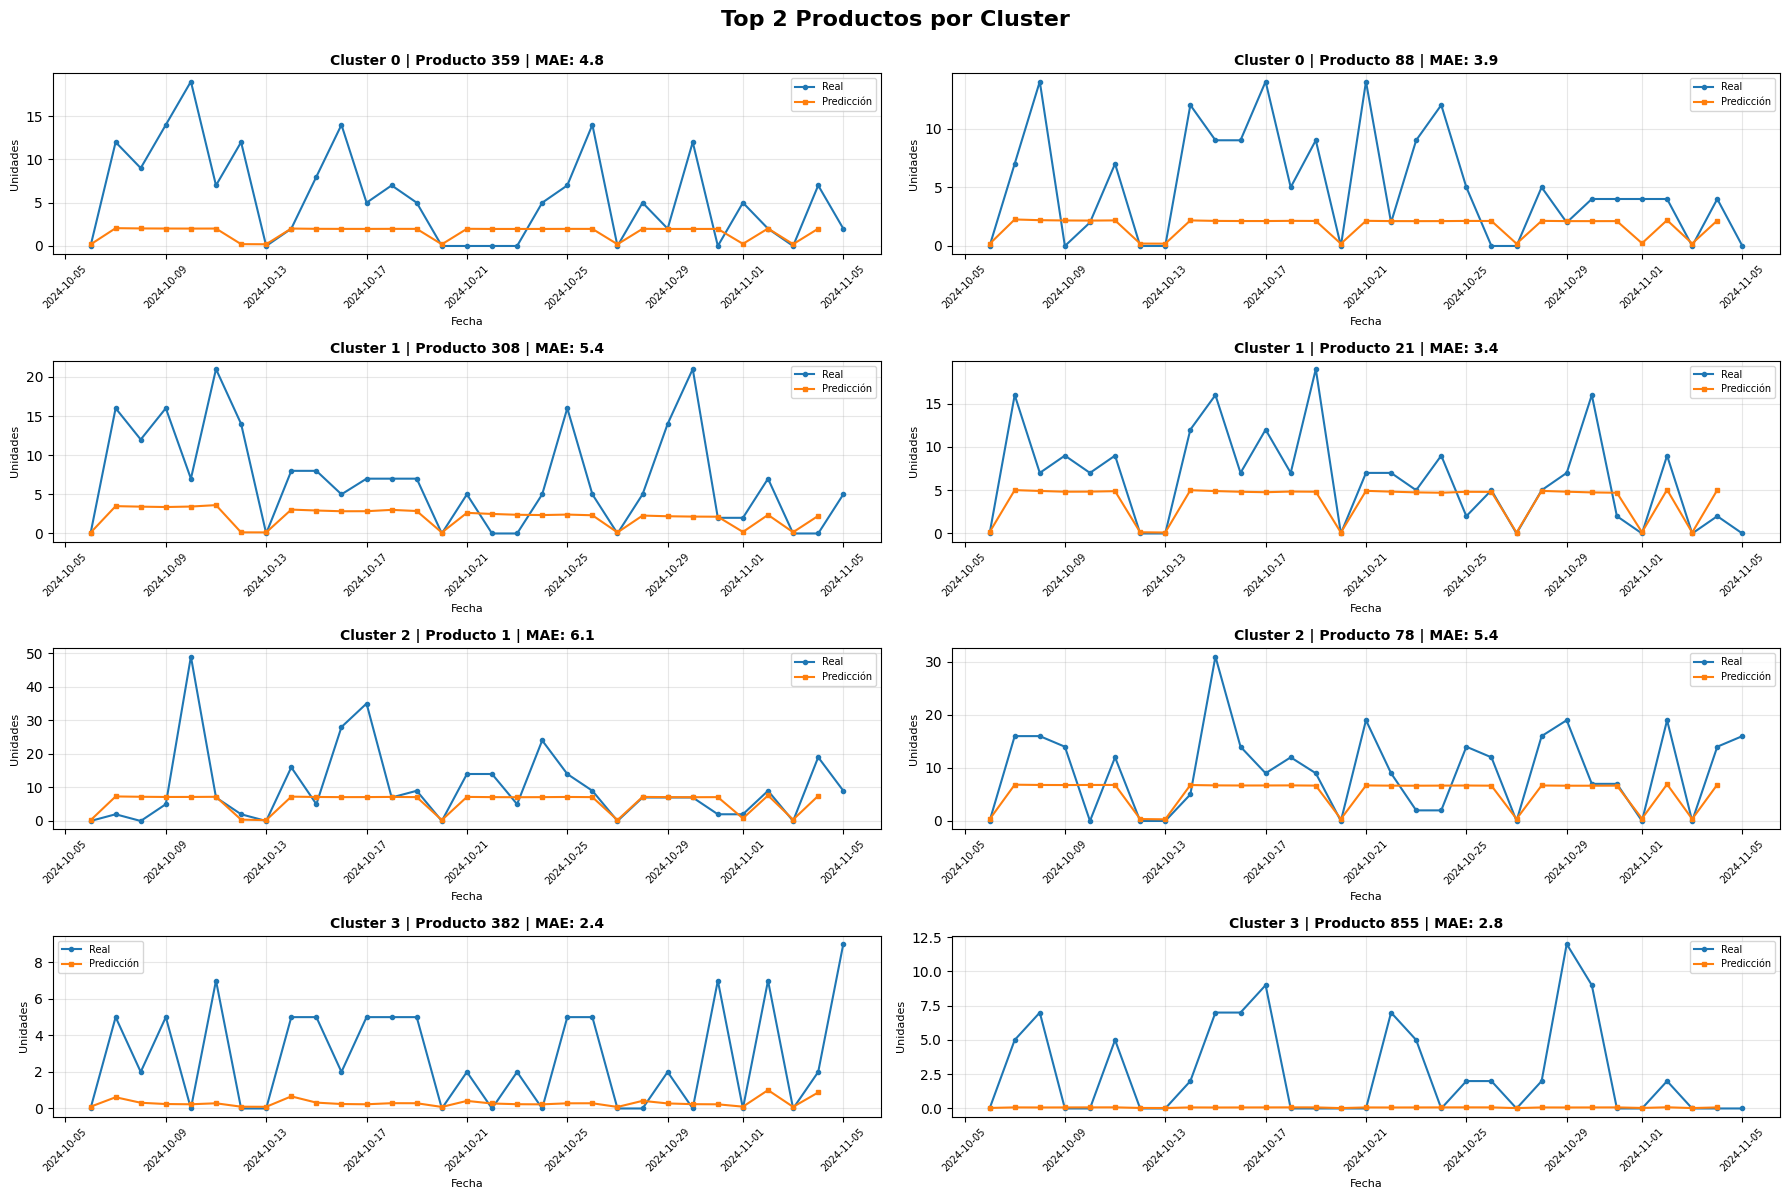

In [15]:
grafico_productos_por_cluster(
    df=df_test_pred,
    col_cluster='Cluster',
    col_producto='producto',
    col_fecha='idSecuencia',
    col_real='udsVenta',
    col_pred='prediccion',
    n_productos_por_cluster=2,
    figsize=(18, 12)
)

## 4. Dashboard de métricas

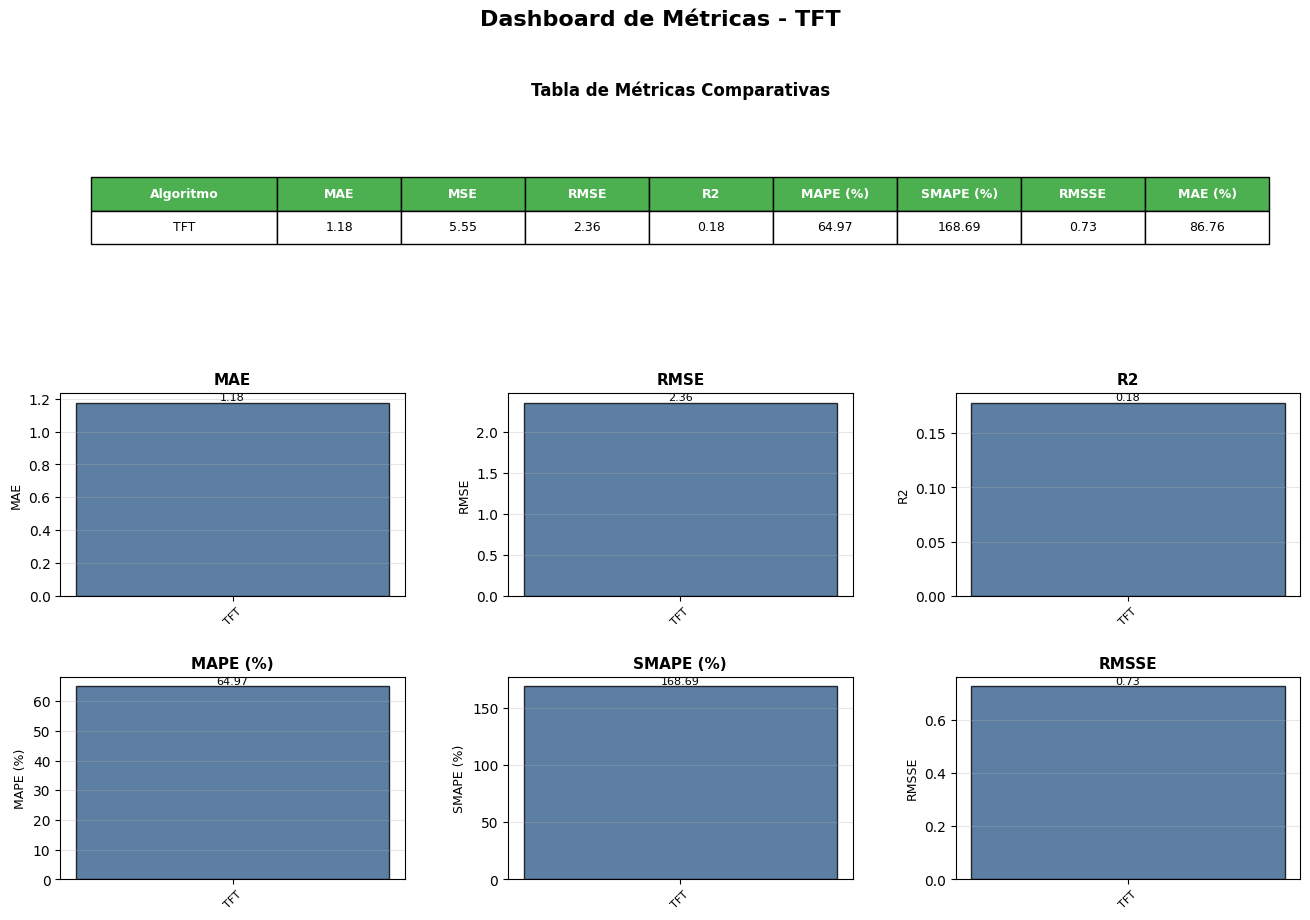

In [16]:
# Preparar diccionario de métricas para el dashboard
# La función espera: {'nombre_algoritmo': {'MAE': x, 'RMSE': y, ...}, ...}
metricas_dict = {}
for m in todas_metricas:
    nombre_algoritmo = m['Algoritmo']
    # Copiar todas las métricas excepto 'Algoritmo'
    metricas_dict[nombre_algoritmo] = {k: v for k, v in m.items() if k != 'Algoritmo'}

dashboard_metricas_dl(
    metricas_dict=metricas_dict,
    titulo='Dashboard de Métricas - TFT',
    figsize=(16, 10)
)

# Guardar resultados

In [17]:
# ============================================================================
# GUARDAR RESULTADOS DE MÉTRICAS
# ============================================================================

print("\n" + "="*100)
print("💾 GUARDANDO RESULTADOS")
print("="*100)

# Convertir lista de métricas a DataFrame
df_resultados = pd.DataFrame(todas_metricas)

# Guardar en CSV
output_path = 'datos/resultados_metricas_tft.csv'
df_resultados.to_csv(output_path, index=False)

print(f"\n✅ Métricas guardadas en: {output_path}")
print(f"   Columnas: {list(df_resultados.columns)}")
print(f"\n📊 Resumen de resultados:")
print(df_resultados.to_string(index=False))
print("="*100)


💾 GUARDANDO RESULTADOS

✅ Métricas guardadas en: datos/resultados_metricas_tft.csv
   Columnas: ['Algoritmo', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE (%)', 'SMAPE (%)', 'RMSSE', 'MAE (%)']

📊 Resumen de resultados:
Algoritmo    MAE    MSE   RMSE     R2  MAPE (%)  SMAPE (%)  RMSSE  MAE (%)
      TFT 1.1758 5.5466 2.3551 0.1783     64.97     168.69 0.7277    86.76
